In [1]:
"""
-- 02_rq1_observed_demand.ipynb --
Análise:
    número total de sessões
    energia total carregada
    número de postos utilizados
    número de EVSE ativos
    número de conectores ativos
    número de utilizadores (2024)

Estrutura
    2.1. Caracterização geral da procura observada 
    2.2  Evolução temporal da procura
    2.2. Padrões de horários e semanais
    2.3  Distribuição espacial da procura
    2.4. Concentração da procura
    2.5. Utilização em dias úteis e fins de semana
    6. Top postos
    7. Análise específica Coimbra
    8. Síntese dos principais resultados
INPUTS:
    v10_carregamentos_mes
    v12_perfil_horario
    v13_perfil_semanal
    v14_procura_posto

OUTPUTS:
    gráficos mensais
    gráficos horários
    top postos
    Coimbra
"""

'\n-- 02_rq1_observed_demand.ipynb --\nAnálise:\n    número total de sessões\n    energia total carregada\n    número de postos utilizados\n    número de EVSE ativos\n    número de conectores ativos\n    número de utilizadores (2024)\n\nEstrutura\n    2.1. Caracterização geral da procura observada \n    2.2  Evolução temporal da procura\n    2.2. Padrões de horários e semanais\n    2.3  Distribuição espacial da procura\n    2.4. Concentração da procura\n    2.5. Utilização em dias úteis e fins de semana\n    6. Top postos\n    7. Análise específica Coimbra\n    8. Síntese dos principais resultados\nINPUTS:\n    v10_carregamentos_mes\n    v12_perfil_horario\n    v13_perfil_semanal\n    v14_procura_posto\n\nOUTPUTS:\n    gráficos mensais\n    gráficos horários\n    top postos\n    Coimbra\n'

In [2]:
# ---------------------------------------
#           Setup e ligação à DB
# ---------------------------------------
import sys
import os

import pandas as pd
import geopandas as gpd
import numpy as np

from sqlalchemy import create_engine
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# adicionar o caminho - sobe um nível
#sys.path.append(os.path.abspath(".."))
#print(os.getcwd())

# encontrar o caminho para a raiz do projeto (/projeto)
projeto_path = os.path.abspath(os.path.join(os.getcwd(), ".."))

# adicionar o novo caminho ao sys.path, caso ainda não esteja
if(projeto_path not in sys.path):
    sys.path.append(projeto_path)


#from libs.map_utils import get_limites_distrito, plot_postos_distrito
import importlib
import libs.map_utils as munic
#importlib.reload(libs.map_utils)
importlib.reload(munic)
#from libs.map_utils import plot_postos_distrito

# definir o diretorio para guardar as figuras e quadros para o relatório
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path("../outputs/tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)


# adicionar a pasta "projeto" ao sys.path
from db.config import DB_CONFIG
from sqlalchemy import create_engine

# função para criar a engine à bd remota
def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}@"
        f"{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
    )

# cria a engine
engine = get_engine()
#print(engine)

In [3]:
# Criação do ambiente para a análise
"""
    - variáveis para analisar: 
        -- por distrito
        -- gráfico - dimensão
        -- labels do gráfico
"""
# distrito
DISTRITO = "Coimbra"

# plot dos gráfics
FIGSIZE = (10, 10)
SHOW_LABELS = True

In [4]:
# ---------------------------------------
# Funções auxiliares
# ---------------------------------------

def read_sql(query):
    return pd.read_sql(query, engine)

def read_gdf(query, geom_col="geom"):
    return gpd.read_postgis(query, engine, geom_col=geom_col)

def anonymise_station_labels(df, id_col="id_charging_station", label_col="station_label"):
    """
        Creates anonymised station labels for sensivel data
    """
    df_out = df.copy()

    df_out[label_col] = [
        f"CS{i:03d}"
        for i in range(1, len(df_out) + 1)
    ]

    return df_out

# 2.1 Caracterização geral da procura observada

In [5]:
# -----------------------------------------------------------------------------------------
# Caracterização geral da procura observada (Exclude Lisboa e Porto)
# -----------------------------------------------------------------------------------------

summary = read_sql("""
    SELECT
        COUNT(*) AS n_sessoes,
        SUM(total_energy) AS energia_total_kwh,
        AVG(total_energy) AS energia_media_kwh,
        COUNT(DISTINCT id_charging_station) AS n_postos_com_procura,
        COUNT(DISTINCT connector_id) AS n_conectores_ativos,
        COUNT(DISTINCT evse_uid_estimado) AS n_evse_estimados_ativos
    FROM v01_sessoes_validas_clean
    WHERE distrito <>'Lisboa' AND distrito <> 'Porto'
    """)

summary

,n_sessoes,energia_total_kwh,energia_media_kwh,n_postos_com_procura,n_conectores_ativos,n_evse_estimados_ativos
0,3783920,8.400124e+07,22.199528,4525,13559,10975


In [6]:
latex_table = (summary.T).to_latex(
    index=False,
    caption="Demand summary indicators",
    label="tab:demand_summary",
    escape=False
)

with open(TABLE_DIR / "tab_4_01_observed_demand_summary_T_exLP.tex", "w") as f:
    f.write(latex_table)

In [7]:
# ---------------------------------------------
# Comparação com a oferta instalada
# ---------------------------------------------

supply_summary = read_sql("""
SELECT
    COUNT(*) AS n_postos_instalados,
    SUM(n_evse) AS n_evse_instalados,
    SUM(n_conectores) AS n_conectores_instalados,
    SUM(potencia_total_kw) AS potencia_total_kw
FROM v20_oferta_posto
WHERE distrito <>'Lisboa' and distrito <> 'Porto'
""")

supply_summary

,n_postos_instalados,n_evse_instalados,n_conectores_instalados,potencia_total_kw
0,7799,17139.0,17364.0,1051148.706


In [8]:
# ---------------------------------------------
# Postos sem procura
# ---------------------------------------------

no_demand = read_sql("""
    SELECT COUNT(*) AS n_postos_sem_procura
    FROM v51_postos_sem_procura
    WHERE distrito <>'Lisboa' and distrito <> 'Porto'
""")

no_demand

,n_postos_sem_procura
0,3274


# 2.3 Temporal analysis

In [9]:
# ---------------------------------------------
# Evolução temporal da procura
# ---------------------------------------------

monthly = read_sql(""" SELECT * FROM v10_carregamentos_mes_exlude_LP ORDER BY mes """)

monthly["mes"] = pd.to_datetime(monthly["mes"])
monthly.head(20)

,mes,n_sessoes,n_postos_ativos,n_evse_raw_ativos,n_conectores_ativos,n_utilizadores,energia_total_kwh,energia_media_kwh,energia_mediana_kwh,duracao_media_min,duracao_mediana_min,custo_total,custo_medio
0,2023-02-01,81190,1624,81190,3243,0,1567445.836,19.305898,15.4900,89.689695,45.116667,3.581576e+05,4.411352
1,2023-03-01,91974,1707,91974,3417,0,1799407.484,19.564306,15.8200,89.283208,44.516667,4.064836e+05,4.419549
2,2023-04-01,96958,1759,96956,3553,0,1925029.032,19.854257,16.2300,85.501041,42.816667,4.368719e+05,4.505785
3,2023-05-01,101103,1816,101103,3627,0,2010948.436,19.890097,16.4400,85.265031,42.233333,4.579434e+05,4.529474
4,2023-06-01,112513,1864,112513,3731,0,2302310.723,20.462620,17.0600,83.854633,41.950000,5.293387e+05,4.704689
5,2023-07-01,135731,1973,135731,3954,0,2806857.947,20.679564,17.3850,83.285386,41.866667,6.786321e+05,4.999831
6,2023-08-01,155160,2045,155160,4293,1,3268723.699,21.066794,17.8600,83.117000,42.166667,8.173425e+05,5.267740
7,2023-09-01,140131,2172,4326,4325,167,2966581.940,21.170062,17.8700,80.450009,40.105817,7.150553e+05,5.102763
8,2023-10-01,129431,2013,4120,4120,33941,2751609.440,21.259277,18.0200,74.311902,40.116667,6.695228e+05,5.172817
9,2023-11-01,129725,2202,4490,4527,33752,2783148.280,21.454217,18.2400,74.719290,40.550000,6.777560e+05,5.224559


## 2.3.1 Monthly chargin patterns

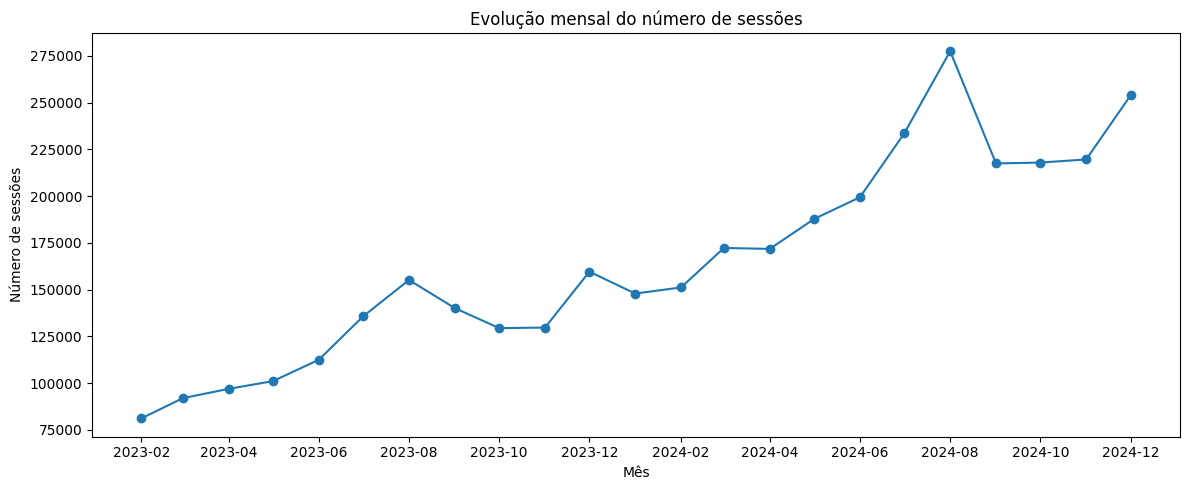

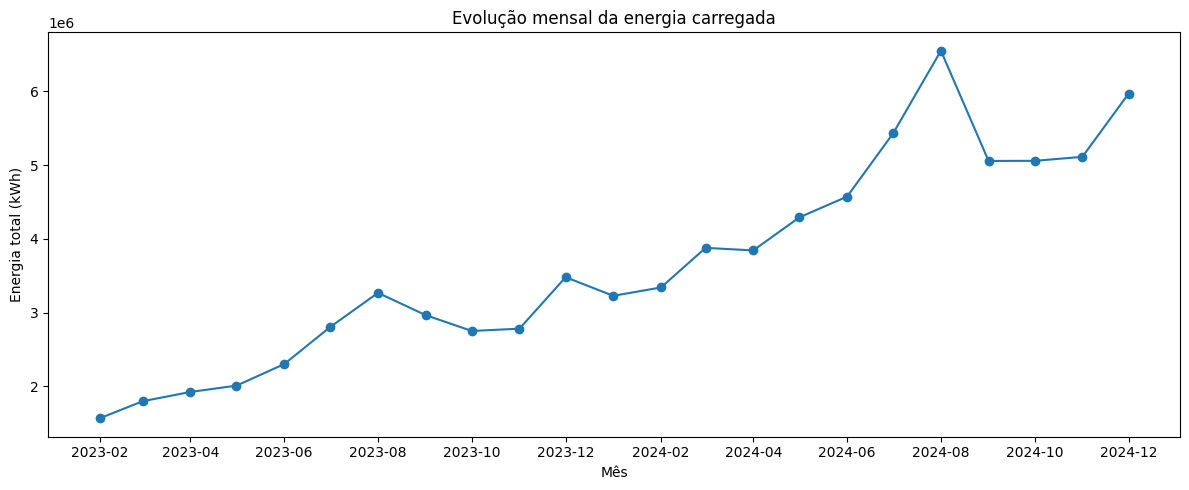

In [10]:
# ------------------------------------------------------------------------------------------
# Plot com a evolução temporal da procura - sessões/energia por Mês
# ------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["mes"], monthly["n_sessoes"], marker="o")
ax.set_xticks(monthly["mes"].iloc[::2])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title("Evolução mensal do número de sessões")
ax.set_xlabel("Mês")
ax.set_ylabel("Número de sessões")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["mes"], monthly["energia_total_kwh"], marker="o")
ax.set_xticks(monthly["mes"].iloc[::2])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title("Evolução mensal da energia carregada")
ax.set_xlabel("Mês")
ax.set_ylabel("Energia total (kWh)")
plt.tight_layout()
plt.show()

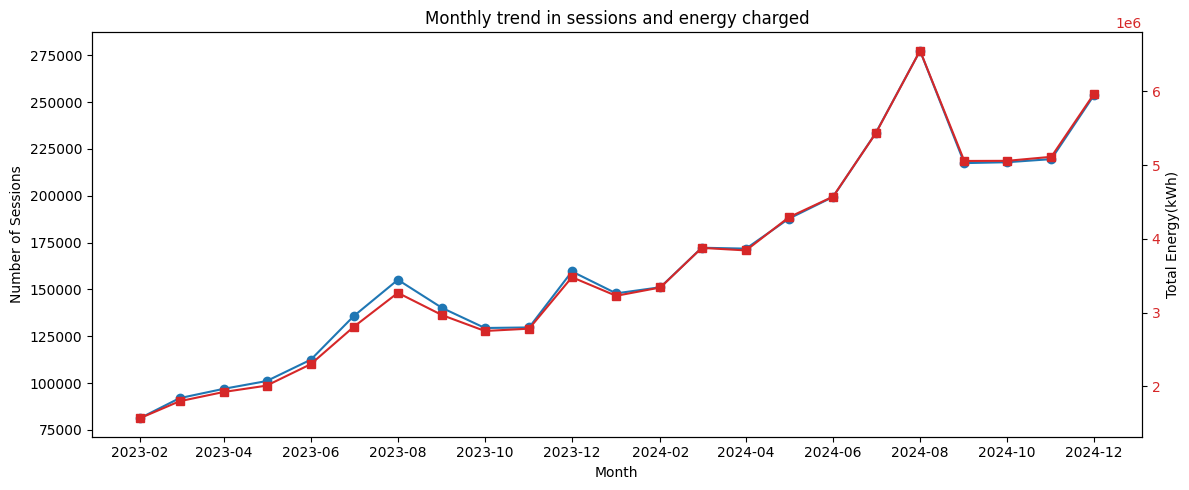

In [11]:
# ---------------------------------------------
# Sessões e energia por Mês
# ---------------------------------------------

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly["mes"], monthly["n_sessoes"], marker="o", color="tab:blue")
ax1.set_xticks(monthly["mes"].iloc[::2])
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Sessions")

ax2 = ax1.twinx()
ax2.plot(monthly["mes"], monthly["energia_total_kwh"], marker="s", color="tab:red")
ax2.set_xticks(monthly["mes"].iloc[::2])
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylabel("Total Energy(kWh)")

plt.title("Monthly trend in sessions and energy charged")

fig.savefig(
    FIG_DIR / f"evolucao_procura_vs_energia_n02_c4_2_2exLP.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

# 2.3 Temporal analysis

In [12]:
# ---------------------------------------------
# Padrões temporais de utilização
# ---------------------------------------------

hourly = read_sql(""" SELECT * FROM v12_perfil_horario_exclude_LP ORDER BY hora_inicio """)
hourly.head()

,hora_inicio,n_sessoes,energia_total_kwh,energia_media_kwh
0,0,44131,1104616.549,25.030399
1,1,27699,686398.535,24.780625
2,2,17393,404877.823,23.278205
3,3,13287,308601.820,23.225846
4,4,13428,310018.706,23.087482


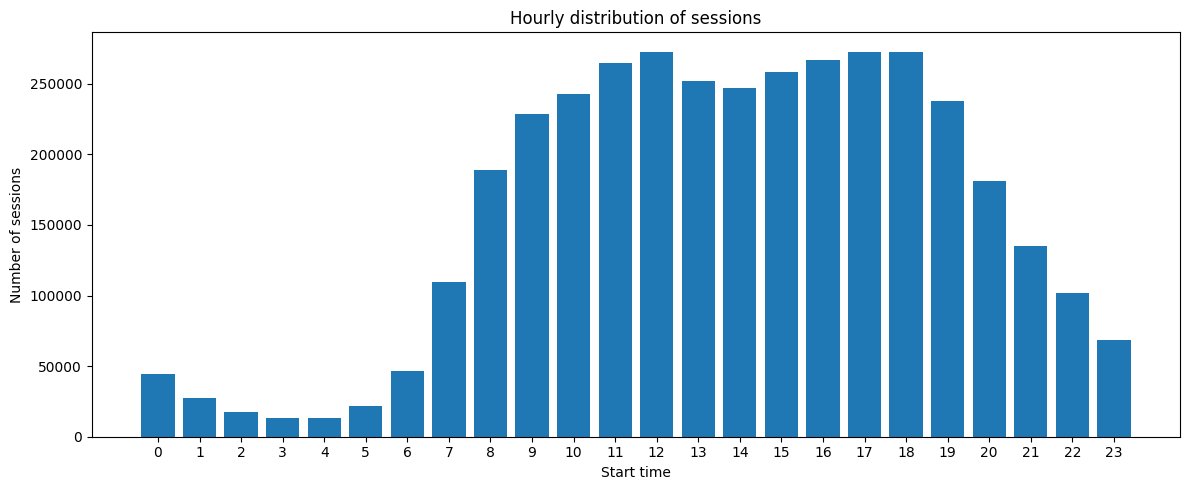

In [13]:
# ---------------------------------------------
# Plot do Perfil do horário
# ---------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly["hora_inicio"], hourly["n_sessoes"])
ax.set_title("Hourly distribution of sessions")
ax.set_xlabel("Start time")
ax.set_ylabel("Number of sessions")
ax.set_xticks(range(0, 24))

fig.savefig(
    FIG_DIR / f"hourly_distribution_of_sessions_n02_c4_2_2_02_exLP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [14]:
# ---------------------------------------------
# Perfil semanal
# ---------------------------------------------


weekly = read_sql(""" SELECT * FROM v13_perfil_semanal_exclude_LP ORDER BY dia_semana """)
weekly.head(8)

,dia_semana,n_sessoes,energia_total_kwh,energia_media_kwh
0,0,542322,1.223471e+07,22.559870
1,1,499905,1.105569e+07,22.115579
2,2,503590,1.108215e+07,22.006302
3,3,514134,1.139047e+07,22.154681
4,4,538103,1.198683e+07,22.276090
5,5,593241,1.316628e+07,22.193820
6,6,592511,1.308338e+07,22.081240


In [15]:
# ---------------------------------------------
# enumeração para os dias da semana
# ---------------------------------------------

dias = {
    0: "Domingo",
    1: "Segunda",
    2: "Terça",
    3: "Quarta",
    4: "Quinta",
    5: "Sexta",
    6: "Sábado"
}

weekly["dia_nome"] = weekly["dia_semana"].map(dias)

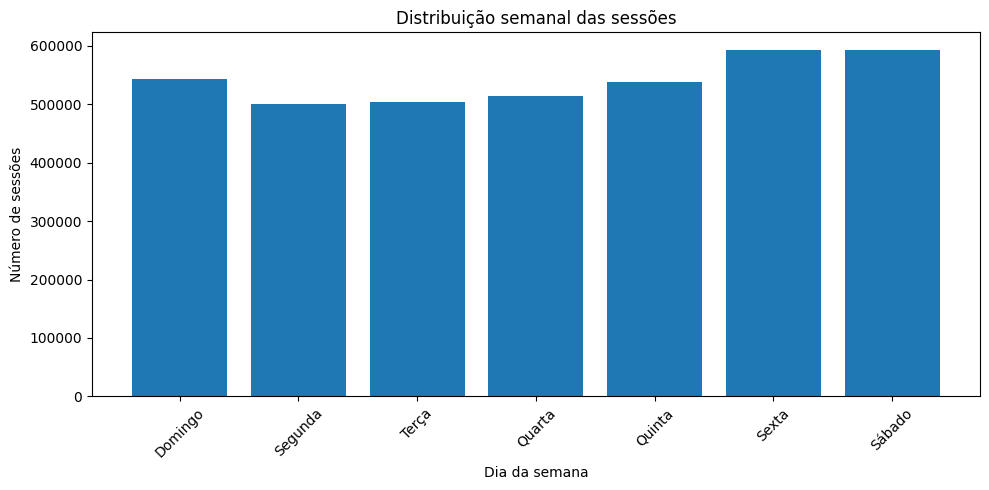

In [16]:
# ---------------------------------------------
# Plot Perfil semanal
# ---------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(weekly["dia_nome"], weekly["n_sessoes"])
ax.set_title("Distribuição semanal das sessões")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Número de sessões")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [17]:
# ---------------------------------------------
# Dias úteis vs Fim-de-semana
# ---------------------------------------------

weekend = read_sql("""
SELECT
    fim_semana,
    COUNT(*) AS n_sessoes,
    SUM(total_energy) AS energia_total_kwh,
    AVG(total_energy) AS energia_media_kwh
FROM v01_sessoes_validas_clean
WHERE distrito <>'Lisboa' and distrito <> 'Porto'
GROUP BY fim_semana
ORDER BY fim_semana
""")

weekend["tipo_dia"] = weekend["fim_semana"].map({
    0: "Weekday", #"Dia útil",
    1: "Weekend" #"Fim de semana"
})

weekend

,fim_semana,n_sessoes,energia_total_kwh,energia_media_kwh,tipo_dia
0,0,2649087,5.868315e+07,22.152216,Weekday
1,1,1134833,2.531809e+07,22.309971,Weekend


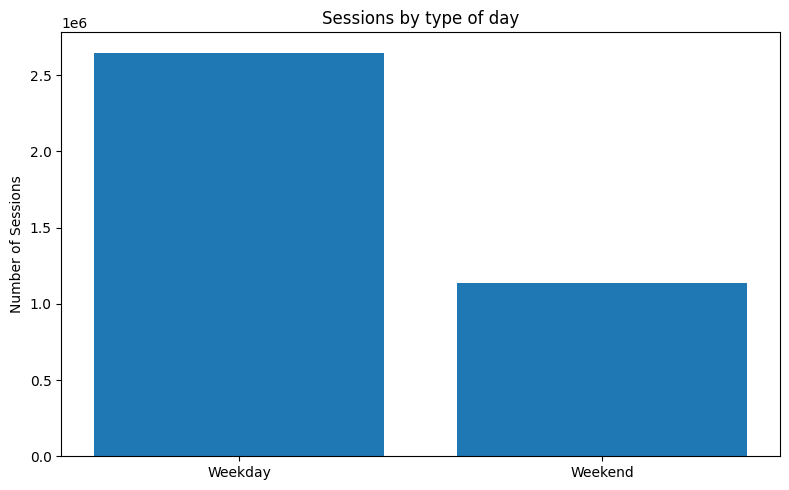

In [19]:
# ---------------------------------------------
# Plot :: Dias úteis vs fim-de-semana
# ---------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(weekend["tipo_dia"], weekend["n_sessoes"])
ax.set_title("Sessions by type of day")
ax.set_ylabel("Number of Sessions")
fig.savefig(
    FIG_DIR / f"sessions_by_type_of_day_n02_c4_2_2_03_exLP.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

In [20]:
# ---------------------------------------------
# Período diurno e horário laboral
# ---------------------------------------------
periodos = read_sql("""
SELECT
    AVG(periodo_diurno::numeric) AS pct_diurno,
    AVG(horario_laboral::numeric) AS pct_horario_laboral
FROM v01_sessoes_validas_clean
WHERE distrito <>'Lisboa' and distrito <> 'Porto'
""")

periodos

,pct_diurno,pct_horario_laboral
0,0.906506,0.418368


## 2.3.2 Weekly charging patterns

In [21]:
df_week = read_sql(""" SELECT * FROM v13_perfil_semanal_normalizado_without_LP """)

In [22]:
df_week
df_week.columns

Index(['dia_semana', 'dia_semana_nome', 'n_sessoes', 'n_dias',
       'sessoes_media_por_dia', 'energia_total_kwh',
       'energia_media_por_dia_kwh', 'energia_media_por_sessao_kwh'],
      dtype='str')

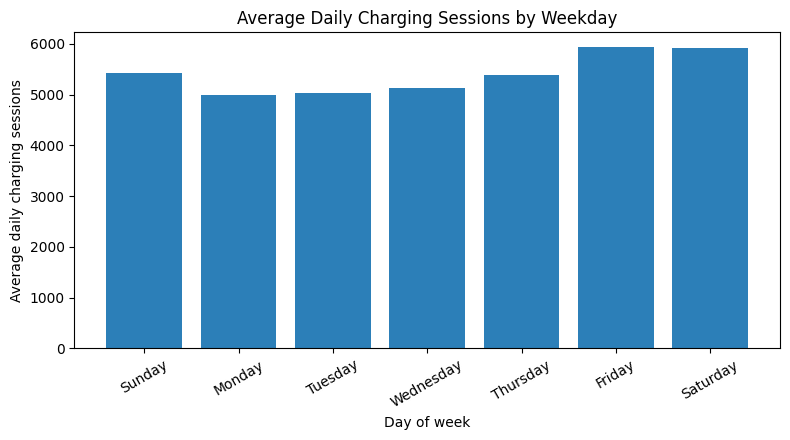

In [23]:
# ---------------------------------------------------------------------------------
# Plot :: média diária de carregamentos por dia da semana
# ---------------------------------------------------------------------------------
dias = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(
    dias,
    df_week["sessoes_media_por_dia"],
    color="#2C7FB8"
)

ax.set_ylabel("Average daily charging sessions")
ax.set_xlabel("Day of week")
ax.set_title("Average Daily Charging Sessions by Weekday")

plt.xticks(rotation=30)
plt.tight_layout()

fig.savefig(
    FIG_DIR / "fig_4_x_average_daily_sessions_weekday_exLP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.3.3 Weekday vs weekend demand

In [24]:
# ---------------------------------------------
# v13_perfil_semanal_normalizado_without_LP
# ---------------------------------------------
df_daytype = read_sql(""" SELECT * FROM v13_weekday_weekend_normalizado_exclude_LP """)

In [ ]:
df_daytype.columns

Index(['tipo_dia', 'n_sessoes', 'n_dias', 'sessoes_media_por_dia',
       'energia_total_kwh', 'energia_media_por_dia_kwh',
       'energia_media_por_sessao_kwh'],
      dtype='str')

In [26]:
df_daytype

,tipo_dia,n_sessoes,n_dias,sessoes_media_por_dia,energia_total_kwh,energia_media_por_dia_kwh,energia_media_por_sessao_kwh
0,weekday,2648973,500,5297.946,5.868143e+07,117362.862692,22.152522
1,weekend,1134833,200,5674.165,2.531809e+07,126590.455820,22.309971


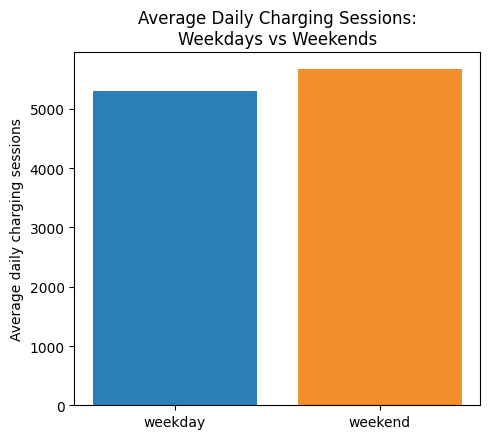

In [27]:
# ---------------------------------------------
# PLOT :: média diária weekday vs weekend
# ---------------------------------------------

fig, ax = plt.subplots(figsize=(5, 4.5))

colors = {
    "weekday": "#2C7FB8",
    "weekend": "#F28E2B"
}

ax.bar(
    df_daytype["tipo_dia"],
    df_daytype["sessoes_media_por_dia"],
    color=[colors[x] for x in df_daytype["tipo_dia"]]
)

ax.set_title("Average Daily Charging Sessions:\nWeekdays vs Weekends")
ax.set_ylabel("Average daily charging sessions")
ax.set_xlabel("")

plt.tight_layout()

fig.savefig(
    FIG_DIR / "fig_4_2_3_weekday_weekend_average_daily_sessions_exclude_LP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.3.4 Hourly charging patterns

In [28]:
# ---------------------------------------------
# View 1: +plot perfil horário global 
# ---------------------------------------------
df_hour = read_sql(""" SELECT * FROM v12_perfil_horario_normalizado_exclude_LP """)

In [29]:
df_hour.columns

Index(['hora_inicio', 'n_sessoes', 'n_dias', 'sessoes_media_por_dia_hora',
       'energia_total_kwh', 'energia_media_por_dia_hora_kwh',
       'energia_media_kwh'],
      dtype='str')

In [30]:
df_hour.head()

,hora_inicio,n_sessoes,n_dias,sessoes_media_por_dia_hora,energia_total_kwh,energia_media_por_dia_hora_kwh,energia_media_kwh
0,0,44131,700,63.044286,1104616.549,1578.023641,25.030399
1,1,27699,699,39.626609,686398.535,981.972153,24.780625
2,2,17393,700,24.847143,404877.823,578.396890,23.278205
3,3,13287,699,19.008584,308601.820,441.490443,23.225846
4,4,13428,699,19.210300,310018.706,443.517462,23.087482


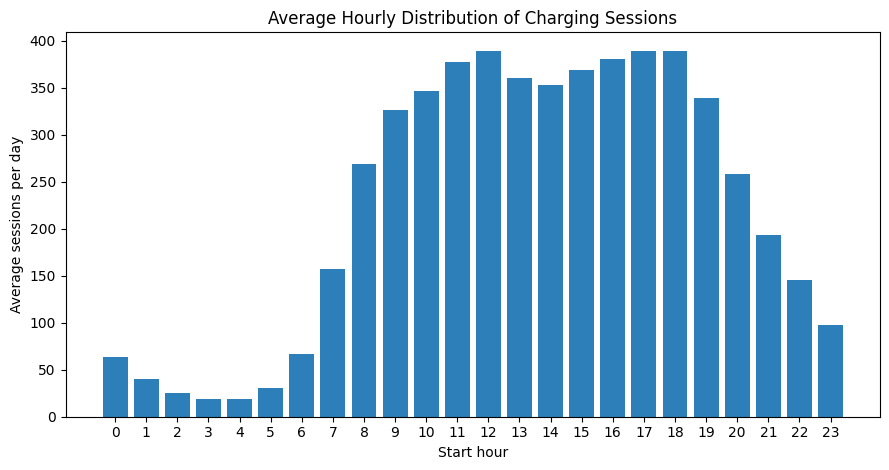

In [31]:
# ---------------------------------------------------------------------------------------
# PLOT (view 1:v12_perfil_horario_normalizado) - Perfil horário global 
# ---------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 4.8))

ax.bar(
    df_hour["hora_inicio"],
    df_hour["sessoes_media_por_dia_hora"],
    color="#2C7FB8"
)

ax.set_title("Average Hourly Distribution of Charging Sessions")
ax.set_xlabel("Start hour")
ax.set_ylabel("Average sessions per day")
ax.set_xticks(range(0, 24))

plt.tight_layout()

fig.savefig(
    FIG_DIR / "fig_4_2_4_average_hourly_charging_sessions_exLP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
df_hour.loc[
    df_hour["sessoes_media_por_dia_hora"].idxmax(),
    ["hora_inicio", "sessoes_media_por_dia_hora"]
]

hora_inicio                    18.000000
sessoes_media_por_dia_hora    389.652857
Name: 18, dtype: float64

In [33]:
# --------------------------------------------------------------------------------------------
# view 2: v13_perfil_horario_weekday_weekend +plot (Perfil Horário weekday vs Weekend)
# --------------------------------------------------------------------------------------------
df_hour_daytype = read_sql(""" SELECT * FROM v13_perfil_horario_weekday_weekend_exclude_LP """)

In [34]:
# df_hour_daytype.columns

In [35]:
df_hour_daytype.head()

,hora_inicio,tipo_dia,n_sessoes,n_dias,sessoes_media_por_dia_hora,energia_total_kwh,energia_media_por_dia_hora_kwh
0,0,weekday,27047,500,54.094000,680400.268,1360.800536
1,0,weekend,17084,200,85.420000,424216.281,2121.081405
2,1,weekday,16405,500,32.810000,407957.403,815.914806
3,1,weekend,11294,199,56.753769,278441.132,1399.201668
4,2,weekday,9858,500,19.716000,229796.513,459.593026


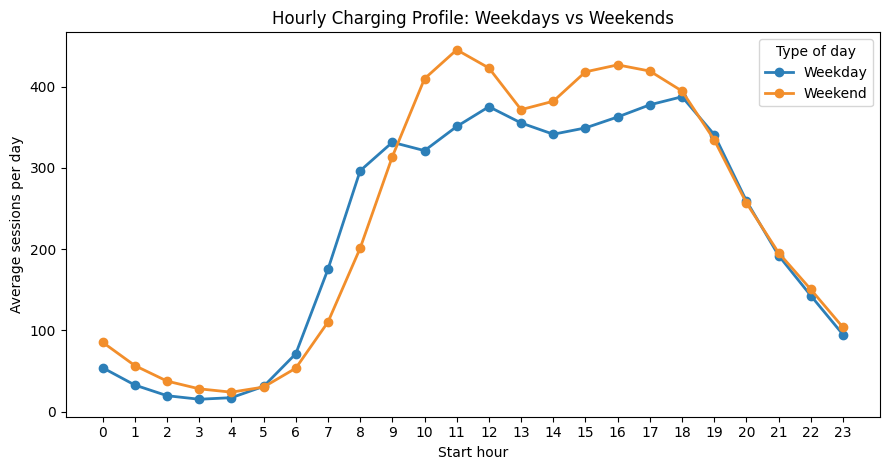

In [36]:
# ------------------------------------------------------------------------------------------
# Plot :: view 2 (v13_perfil_horario_weekday_weekend) - Perfil Horário weekday vs Weekend
# ---------------------------------------------

fig, ax = plt.subplots(figsize=(9, 4.8))

colors = {
    "weekday": "#2C7FB8",
    "weekend": "#F28E2B"
}

for tipo_dia, color in colors.items():
    df_temp = df_hour_daytype[df_hour_daytype["tipo_dia"] == tipo_dia]

    ax.plot(
        df_temp["hora_inicio"],
        df_temp["sessoes_media_por_dia_hora"],
        marker="o",
        linewidth=2,
        color=color,
        label=tipo_dia.capitalize()
    )

ax.set_title("Hourly Charging Profile: Weekdays vs Weekends")
ax.set_xlabel("Start hour")
ax.set_ylabel("Average sessions per day")
ax.set_xticks(range(0, 24))
ax.legend(title="Type of day")

plt.tight_layout()

fig.savefig(
    FIG_DIR / "fig_4_2_3_hourly_profile_weekday_weekend_exLP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
df_hour_daytype.loc[
    df_hour_daytype.groupby("tipo_dia")["sessoes_media_por_dia_hora"].idxmax(),
    ["tipo_dia", "hora_inicio", "sessoes_media_por_dia_hora"]
]

,tipo_dia,hora_inicio,sessoes_media_por_dia_hora
36,weekday,18,387.658
23,weekend,11,445.435


# 2.4 Distribuição espacial da procura por posto

In [38]:
# ---------------------------------------------
# Distribuição espacial da procura por posto
# ---------------------------------------------

postos = read_gdf(""" SELECT * FROM v14_procura_posto_clean where distrito <>'Lisboa' and distrito <>'Porto' """)

postos = postos.set_crs(epsg=3763, allow_override=True)

postos = anonymise_station_labels(postos)

#postos = postos.sort_values("n_sessoes", ascending=True)
#postos.loc[:, postos.columns != "id_charging_station"].head(10)

cols_to_show = [
    "station_label",
    *postos.columns.drop(["station_label", "id_charging_station", "geom"])
]
postos[cols_to_show].head()


,station_label,distrito,municipio,dtmn,nuts_3,nuts_2,nuts_1,n_sessoes,n_conectores_ativos,n_evse_estimados_ativos,...,pct_noite,pct_noite_tardia,pct_inverno,pct_primavera,pct_verao,pct_outono,pct_periodo_descanso,pct_feriado,pct_feriado_nacional,pct_feriado_municipal
0,CS001,Faro,Albufeira,0801,Algarve,Algarve,Continente,1593,4,3,...,0.205901,0.068424,0.055242,0.222850,0.476460,0.245449,0.344005,0.044570,0.038920,0.005650
1,CS002,Faro,Albufeira,0801,Algarve,Algarve,Continente,838,4,3,...,0.213604,0.063246,0.065632,0.317422,0.373508,0.243437,0.318616,0.045346,0.039379,0.005967
2,CS003,Faro,Albufeira,0801,Algarve,Algarve,Continente,73,2,2,...,0.315068,0.095890,0.219178,0.178082,0.410959,0.191781,0.465753,0.013699,0.013699,0.000000
3,CS004,Faro,Albufeira,0801,Algarve,Algarve,Continente,61,2,2,...,0.377049,0.131148,0.163934,0.098361,0.655738,0.081967,0.557377,0.032787,0.032787,0.000000
4,CS005,Faro,Albufeira,0801,Algarve,Algarve,Continente,261,4,3,...,0.222222,0.111111,0.065134,0.176245,0.659004,0.099617,0.409962,0.084291,0.068966,0.015326


In [39]:
postos[[
    "primeira_sessao",
    "meses_ativos",
    "pct_verao",
    "pct_inverno"
]].sort_values("primeira_sessao")

,primeira_sessao,meses_ativos,pct_verao,pct_inverno
2600,2023-01-30 18:48:14.000,21,0.258687,0.208494
1848,2023-01-30 19:19:17.000,24,0.365793,0.157303
3838,2023-01-31 07:54:57.000,18,0.150515,0.251546
2630,2023-01-31 13:35:45.000,13,0.144928,0.181159
4141,2023-01-31 15:56:00.000,15,0.164773,0.340909
...,...,...,...,...
514,2024-12-29 15:52:11.349,1,0.000000,1.000000
1161,2024-12-30 13:58:43.000,1,0.000000,1.000000
3618,2024-12-30 15:11:13.000,1,0.000000,1.000000
4132,2024-12-30 20:42:03.641,1,0.000000,1.000000


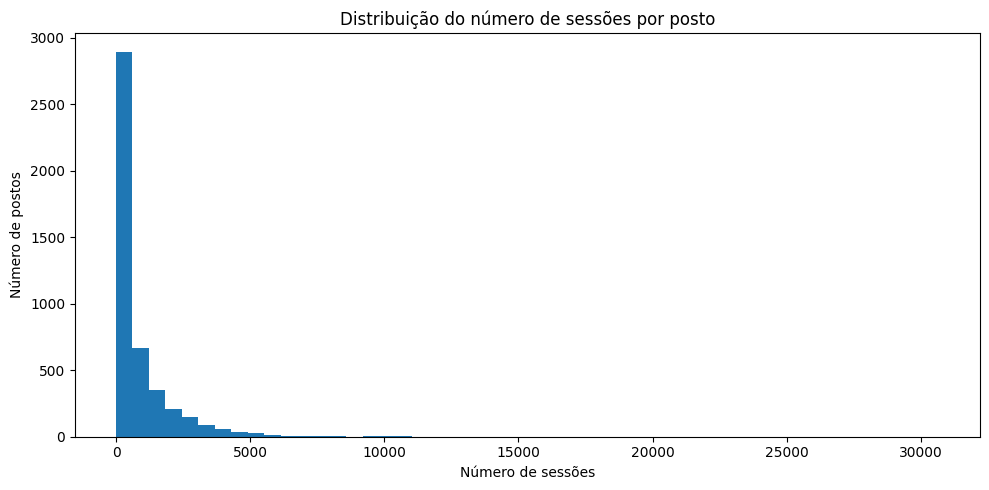

In [40]:
# ---------------------------------------------
# Plot distribuição espacial sessões por posto
# ---------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(postos["n_sessoes"], bins=50)
ax.set_title("Distribuição do número de sessões por posto")
ax.set_xlabel("Número de sessões")
ax.set_ylabel("Número de postos")
plt.tight_layout()
plt.show()

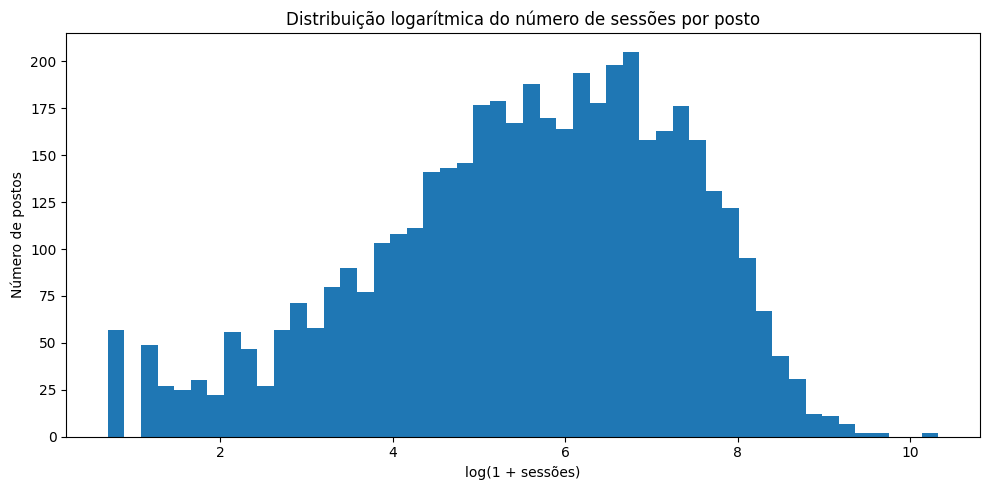

In [41]:
# ---------------------------------------------------
# plot 2 distribuição logarítmica sessões por posto
# ---------------------------------------------------

postos["log_sessoes"] = np.log1p(postos["n_sessoes"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(postos["log_sessoes"], bins=50)
ax.set_title("Distribuição logarítmica do número de sessões por posto")
ax.set_xlabel("log(1 + sessões)")
ax.set_ylabel("Número de postos")
plt.tight_layout()
plt.show()

In [42]:
# ---------------------------------------------
# Concentração da procura
# ---------------------------------------------

postos_conc = postos.copy()

postos_conc["pct_sessoes"] = (
    postos_conc["n_sessoes"] /
    postos_conc["n_sessoes"].sum()
)

postos_conc = postos_conc.sort_values(
    "n_sessoes",
    ascending=False
)

postos_conc["pct_acumulada"] = postos_conc["pct_sessoes"].cumsum()

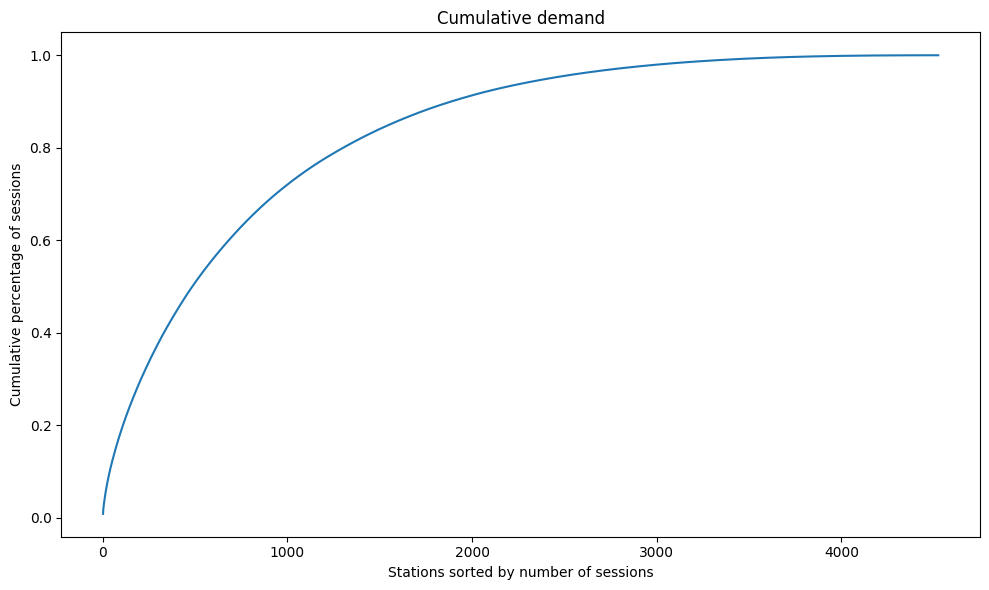

50% das sessões estão concentradas em 485 postos.
80% das sessões estão concentradas em 1301 postos.
Os postos que concentram 80% das sessões representam 28.8% dos postos com procura observada.


In [43]:
# ---------------------------------------------
# Plot da concentração da procura
# ---------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    range(1, len(postos_conc) + 1),
    postos_conc["pct_acumulada"]
)

ax.set_title("Cumulative demand")
ax.set_xlabel("Stations sorted by number of sessions")
ax.set_ylabel("Cumulative percentage of sessions")
plt.tight_layout()

fig.savefig(
    FIG_DIR / f"Cumulative_demand_n02_c4_2_3_01.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# -- output
total_postos = len(postos_conc)

p50 = (postos_conc["pct_acumulada"] <= 0.50).sum()
p80 = (postos_conc["pct_acumulada"] <= 0.80).sum()

print(f"50% das sessões estão concentradas em {p50} postos.")
print(f"80% das sessões estão concentradas em {p80} postos.")
print(f"Os postos que concentram 80% das sessões representam {100*p80/total_postos:.1f}% dos postos com procura observada.")


In [44]:
# ---------------------------------------------
# Top 20 postos
# ---------------------------------------------

top20 = postos.sort_values("n_sessoes", ascending=False).head(20)

top20[[
    "station_label",
    "distrito",
    "municipio",
    "n_sessoes",
    "energia_total_kwh",
    "sessoes_mes_ativo",
    "kwh_mes_ativo", 
    "n_utilizadores_unicos",
    "sessoes_por_utilizador",
    "energia_media_kwh",
    "duracao_media_min",
]]

,station_label,distrito,municipio,n_sessoes,energia_total_kwh,sessoes_mes_ativo,kwh_mes_ativo,n_utilizadores_unicos,sessoes_por_utilizador,energia_media_kwh,duracao_media_min
2043,CS2044,Leiria,Leiria,30675,1102678.533,2556.250000,91889.877750,13761,2.229126,35.947140,28.840062
2044,CS2045,Leiria,Leiria,28867,1063291.433,2405.583333,88607.619417,13473,2.142581,36.834151,28.947996
180,CS181,Beja,Almodôvar,15618,553474.093,1301.500000,46122.841083,9146,1.707632,35.438218,26.624966
667,CS668,Braga,Braga,14962,436413.975,650.521739,18974.520652,2493,6.001604,29.168158,40.347970
181,CS182,Beja,Almodôvar,13510,474726.001,1125.833333,39560.500083,8121,1.663588,35.138860,29.753622
3855,CS3856,Santarém,Santarém,11795,327340.258,512.826087,14232.185130,5967,1.976705,27.752459,24.422436
1291,CS1292,Aveiro,Estarreja,11453,300529.540,477.208333,12522.064167,5257,2.178619,26.240246,22.413575
1093,CS1094,Coimbra,Cantanhede,10762,318267.553,467.913043,13837.719696,5012,2.147247,29.573272,24.621303
3857,CS3858,Santarém,Santarém,10741,321427.544,467.000000,13975.110609,5153,2.084417,29.925290,26.039982
293,CS294,Setúbal,Almada,10376,325681.700,691.733333,21712.113333,2979,3.483048,31.387982,39.459132


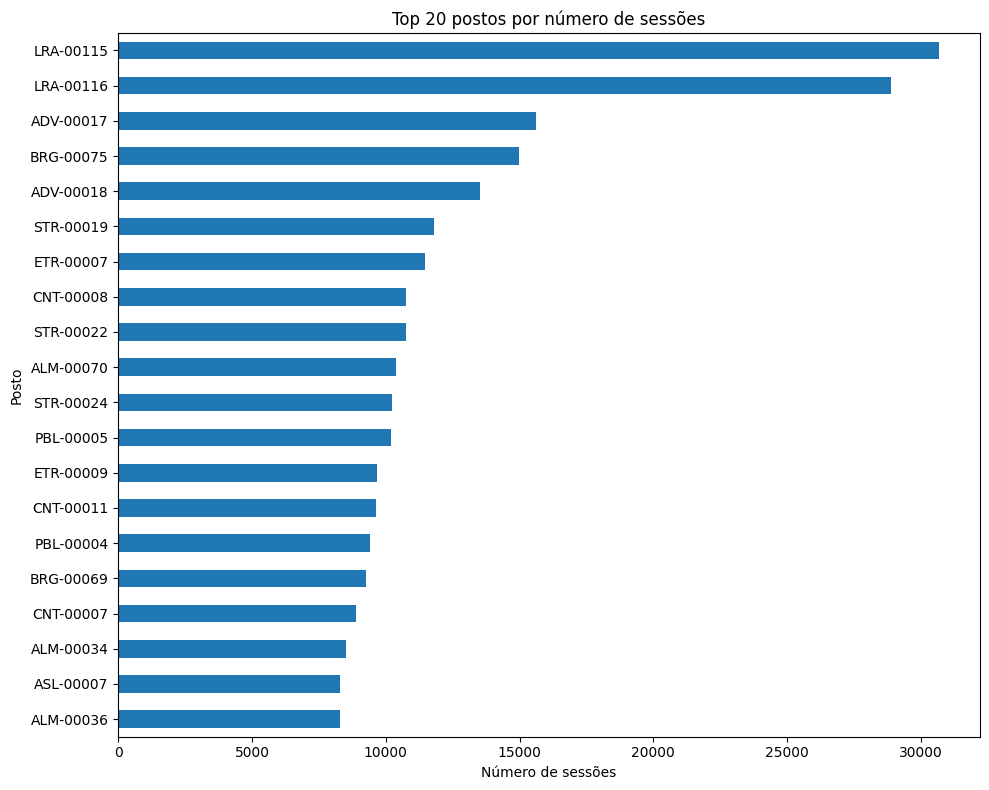

In [45]:
# ---------------------------------------------
# Plot top 20 postos por sessões
# ---------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

top20.sort_values("n_sessoes").plot(
    x="id_charging_station",
    y="n_sessoes",
    kind="barh",
    ax=ax,
    legend=False
)

ax.set_title("Top 20 postos por número de sessões")
ax.set_xlabel("Número de sessões")
ax.set_ylabel("Posto")
plt.tight_layout()
plt.show()


In [46]:
# ---------------------------------------------
#  Top 10 postos
# ---------------------------------------------

top10 = postos.sort_values("n_sessoes", ascending=False).head(10)

top10_pub = anonymise_station_labels(top10)

#top10_pub[["station_label", "n_sessoes", "energia_total_kwh"]]

top10_pub[[
    "station_label",
    "distrito",
    "municipio",
    "n_sessoes",
    "energia_total_kwh",
    "n_utilizadores_unicos"
]]

top10_export = top10_pub[[
    "station_label",
    "distrito",
    "municipio",
    "n_sessoes",
    "energia_total_kwh",
    "n_utilizadores_unicos"
]].copy()

top10_export = top10_export.rename(columns={
    "station_label": "Station",
    "distrito": "District",
    "municipio": "Municipality",
    "n_sessoes": "Sessions",
    "n_utilizadores_unicos": "Unique Users"
})

top10_export["Energy (MWh)"] = (
    top10_export["energia_total_kwh"] / 1000
).round(1)

top10_export["Energy (MWh)"] = (
    top10_export["Energy (MWh)"]
    .map("{:,.1f}".format)
)

top10_export = top10_export.drop(columns=["energia_total_kwh"])

top10_export["Sessions"] = (
    top10_export["Sessions"]
    .astype(int)
    .map("{:,}".format)
)

top10_export["Unique Users"] = (
    top10_export["Unique Users"]
    .astype(int)
    .map("{:,}".format)
)

top10_export


,Station,District,Municipality,Sessions,Unique Users,Energy (MWh)
2043,CS001,Leiria,Leiria,"30,675","13,761","1,102.7"
2044,CS002,Leiria,Leiria,"28,867","13,473","1,063.3"
180,CS003,Beja,Almodôvar,"15,618","9,146",553.5
667,CS004,Braga,Braga,"14,962","2,493",436.4
181,CS005,Beja,Almodôvar,"13,510","8,121",474.7
3855,CS006,Santarém,Santarém,"11,795","5,967",327.3
1291,CS007,Aveiro,Estarreja,"11,453","5,257",300.5
1093,CS008,Coimbra,Cantanhede,"10,762","5,012",318.3
3857,CS009,Santarém,Santarém,"10,741","5,153",321.4
293,CS010,Setúbal,Almada,"10,376","2,979",325.7


In [47]:
# -----------------------------------------------------------------------------------------
# save do quadro como ficheiro latex para usar no overleaf 
# -----------------------------------------------------------------------------------------

latex_table = top10_export.to_latex(
    index=False,
    caption="Top 10 stations by number of sessions",
    label="tab:top_10_stations_sessions",
    escape=False
)

with open(TABLE_DIR / "tab_4_2_3_02_top_10_postos_por_num_sessoes.tex", "w") as f:
    f.write(latex_table)